In [1]:
# After learning the Datacamp course from TG, here are some viable model architectures I believe will work for our seq_2_seq model

In [2]:
import tensorflow as tf

2025-07-09 19:34:58.255392: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-09 19:34:58.291624: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-09 19:34:58.291648: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-09 19:34:58.292468: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-09 19:34:58.298885: I tensorflow/core/platform/cpu_feature_guar

In [3]:
inp_layer = tf.keras.layers.Input(shape = (13, 32))

lstm_layer = tf.keras.layers.LSTM(64, return_state = True, activation = 'relu')

lstm_out, lstm_state, lstm_c = lstm_layer(inp_layer)

2025-07-09 19:35:00.112331: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:86:00.0, compute capability: 7.0


In [4]:
encoder_model = tf.keras.models.Model(inputs = inp_layer, outputs = lstm_state)

In [5]:
encoder_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 13, 32)]          0         
                                                                 
 lstm (LSTM)                 [(None, 64),              24832     
                              (None, 64),                        
                              (None, 64)]                        
                                                                 
Total params: 24832 (97.00 KB)
Trainable params: 24832 (97.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [6]:
lstm_out.shape

TensorShape([None, 64])

In [7]:
# repeat the final context vector for the output time stpe number - which is 7
rep_layer = tf.keras.layers.RepeatVector(7)(lstm_out)

In [8]:
lstm_dec_layer = tf.keras.layers.LSTM(64, return_sequences = True, activation = 'relu')

In [9]:
decoder_out1 = lstm_dec_layer(rep_layer, initial_state=[lstm_state, lstm_c])

In [10]:
# define another LSTM? with 32 hidden?
lstm_dec_layer2 = tf.keras.layers.LSTM(32, return_sequences = True, activation = 'relu')

In [11]:
decoder_out2 = lstm_dec_layer2(decoder_out1)

In [12]:
decoder_out2.shape

TensorShape([None, 7, 32])

In [13]:
# see that we have the needed shape- so no need of a dense layer

In [14]:
proposed_seq2seq_0 = tf.keras.models.Model(inputs = inp_layer, outputs = decoder_out2)

In [15]:
proposed_seq2seq_0.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 13, 32)]             0         []                            
                                                                                                  
 lstm (LSTM)                 [(None, 64),                 24832     ['input_1[0][0]']             
                              (None, 64),                                                         
                              (None, 64)]                                                         
                                                                                                  
 repeat_vector (RepeatVecto  (None, 7, 64)                0         ['lstm[0][0]']                
 r)                                                                                         

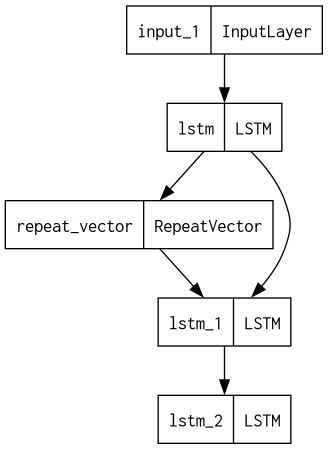

In [16]:
tf.keras.utils.plot_model(proposed_seq2seq_0)

In [17]:
# maybe this is a better model as we do not use a dense layer? - might want to explore this?

In [18]:
# Seems this model is an incomplete model, so lets go forward with the original models. Something to clarify is the original model does not use a timedistributed layer as a wrapper as now Dense allows 3D inputs. What's the difference between these two models. Let's find out

In [19]:
# Old architecture we have implemented - Notice that the last dense layer does not use a TimeDistributed wrapper for the Dense layer, and only a Dense layer. The new Dense layer in keras 2.10+ can accept 3D inputs hence the Dense layer not wrapped. (Originally, Dense layer only accepted 2D inputs, therefore a timedistributed layer was necessray, but not anymore). But, what is the difference in these two networks. Let's write the original architecture, and the alternative to that using the timedistributed layer.

In [20]:
# Original architecture

# Our story
# We have 20 time points. At each time step we have 32 features - use the first 13 time steps to predict the output for the final 7 time steps
input_ts = 13
output_ts = 7
input_features = 32
output_features = 32

# Let's build the model as follows

# Encoder
en_input = tf.keras.layers.Input(shape = (input_ts, input_features))

en_lstm = tf.keras.layers.LSTM(64, activation = 'relu', return_state = True, return_sequences = False)

en_output, en_state_h, en_state_c = en_lstm(en_input)

# Decoder
# repeat the context vector for the number of output timesteps
de_input = tf.keras.layers.RepeatVector(output_ts)(en_output)

de_lstm = tf.keras.layers.LSTM(64, activation = 'relu', return_state = False, return_sequences = True)

de_output = de_lstm(de_input, initial_state = [en_state_h, en_state_c])

dense_output = tf.keras.layers.Dense(output_features)(de_output)

original_model = tf.keras.models.Model(inputs = en_input, outputs = dense_output)

In [21]:
original_model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 13, 32)]             0         []                            
                                                                                                  
 lstm_3 (LSTM)               [(None, 64),                 24832     ['input_2[0][0]']             
                              (None, 64),                                                         
                              (None, 64)]                                                         
                                                                                                  
 repeat_vector_1 (RepeatVec  (None, 7, 64)                0         ['lstm_3[0][0]']              
 tor)                                                                                       

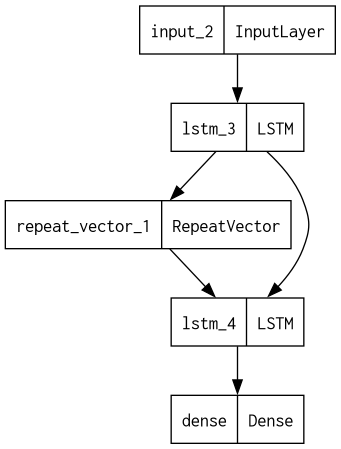

In [22]:
tf.keras.utils.plot_model(original_model)

In [23]:
# Okay, now do the same architecture, but now wrap the Dense layer in a timedistributed layer

In [24]:
input_ts = 13
output_ts = 7
input_features = 32
output_features = 32

# Let's build the model as follows

# Encoder
en_input_alt = tf.keras.layers.Input(shape = (input_ts, input_features))

en_lstm_alt = tf.keras.layers.LSTM(64, activation = 'relu', return_state = True, return_sequences = False)

en_output_alt, en_state_h_alt, en_state_c_alt = en_lstm(en_input_alt)

# Decoder
# repeat the context vector for the number of output timesteps
de_input_alt = tf.keras.layers.RepeatVector(output_ts)(en_output_alt)

de_lstm_alt = tf.keras.layers.LSTM(64, activation = 'relu', return_state = False, return_sequences = True)

de_output_alt = de_lstm(de_input_alt, initial_state = [en_state_h_alt, en_state_c_alt])

dense_output_alt = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(output_features))(de_output_alt)

original_model_alt = tf.keras.models.Model(inputs = en_input_alt, outputs = dense_output_alt)

In [25]:
original_model_alt.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 13, 32)]             0         []                            
                                                                                                  
 lstm_3 (LSTM)               [(None, 64),                 24832     ['input_3[0][0]']             
                              (None, 64),                                                         
                              (None, 64)]                                                         
                                                                                                  
 repeat_vector_2 (RepeatVec  (None, 7, 64)                0         ['lstm_3[1][0]']              
 tor)                                                                                       

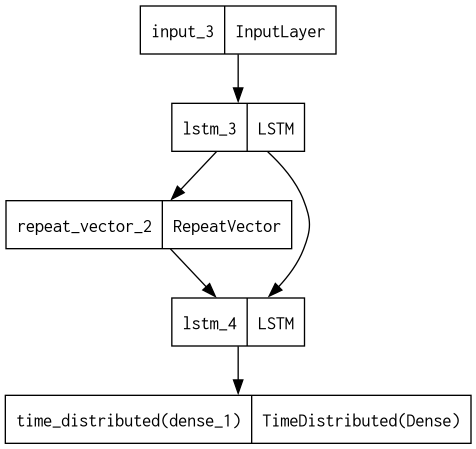

In [26]:
tf.keras.utils.plot_model(original_model_alt)

In [27]:
# Both networks have the same number of parameters regardless of how the Dense layer is used. The summary is not giving any clue about what's different, need to find this out.

In [28]:
# It is seen that both these methods behave identically in modern tf keras. Let's understand what exactly happense in a TimeDistributed layer as these can be used to wrap other layers lile Conv2D, LSTM and sometimes entire submodels. This is what we need to do as Dr. Ghosh suggetes (wrapping an entire submodel)